# 6 - Funnels

Visualizes user retention and drop-off across multiple funnel types:
1. **Session count funnel** — how many users return for session 2, 3, 4…
2. **Engagement funnel** — signup → first discovery → like/superlike → repeated engagement
3. **Platform comparison** — iOS vs Android retention
4. **Spotify vs non-Spotify** — authenticated vs unauthenticated users
5. **Cohort weekly retention** — week-over-week return rate by signup cohort

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

%run db.py

## Shared helpers

In [3]:
def get_session_funnel(startdate, enddate, extra_where=''):
    """Returns a DataFrame with columns [num_sessions, num_users].
    A session is defined as a distinct calendar day with at least one rating
    (like, superlike, or dislike) in user_songs / unliked_songs.
    extra_where is appended to the WHERE clause on the users table (e.g. platform filter).
    """
    sql = f"""
        SELECT num_sessions, COUNT(*) AS num_users
        FROM (
            SELECT r.user_id, COUNT(DISTINCT DATE(r.timestamp)) AS num_sessions
            FROM (
                SELECT user_id, timestamp FROM user_songs
                WHERE timestamp > '{startdate}' AND timestamp < '{enddate}'
                UNION ALL
                SELECT user_id, timestamp FROM unliked_songs
                WHERE timestamp > '{startdate}' AND timestamp < '{enddate}'
            ) r
            INNER JOIN users u ON u.id = r.user_id
            WHERE u.timestamp > '{startdate}'
              AND u.timestamp < '{enddate}'
              {extra_where}
            GROUP BY r.user_id
        ) t
        GROUP BY num_sessions
        ORDER BY num_sessions ASC
    """
    return pd.DataFrame(DB.fetch(sql))


def retention_curve(df):
    """From a session-count DataFrame, compute fraction of users who reach each session N.
    Returns a Series indexed by num_sessions.
    """
    df = df.sort_values('num_sessions').set_index('num_sessions')
    total = df['num_users'].sum()
    # reverse cumsum: users who had >= N sessions
    retained = df['num_users'][::-1].cumsum()[::-1]
    return (retained / total).rename('retention')


def plot_retention_curves(curves, labels, title, max_sessions=20):
    """Plot multiple retention curves on the same axes.
    curves: list of Series from retention_curve()
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for curve, label in zip(curves, labels):
        curve = curve[curve.index <= max_sessions]
        axes[0].plot(curve.index, curve.values, marker='o', markersize=4, label=label)
        axes[1].plot(curve.index, curve.values, marker='o', markersize=4, label=label)

    axes[0].set_title(f'{title} — Retention')
    axes[0].set_xlabel('Session number (distinct active days)')
    axes[0].set_ylabel('Fraction of users retained')
    axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_title(f'{title} — Retention (log scale)')
    axes[1].set_xlabel('Session number (distinct active days)')
    axes[1].set_yscale('log')
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_funnel_bars(stages, counts, title):
    """Horizontal funnel bar chart. stages and counts are parallel lists."""
    pcts = [c / counts[0] for c in counts]
    colors = plt.cm.Blues_r(np.linspace(0.2, 0.7, len(stages)))

    fig, ax = plt.subplots(figsize=(10, 0.7 * len(stages) + 1.5))
    ax.barh(range(len(stages)), pcts, color=colors, edgecolor='white')
    ax.set_yticks(range(len(stages)))
    ax.set_yticklabels(stages)
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xlabel('% of users at first stage')
    ax.set_title(title)

    for i, (p, c) in enumerate(zip(pcts, counts)):
        ax.text(p + 0.005, i, f'{p:.1%}  ({c:,})', va='center', fontsize=9)

    ax.set_xlim(0, 1.3)
    plt.tight_layout()
    plt.show()

---
## 1. Session count funnel — overall
Of all users who signed up, how many came back for session 2, 3, 4…?

In [4]:
START, END = '2024-01-01', '2025-01-01'

df_all = get_session_funnel(START, END)
print(f"Total users: {df_all['num_users'].sum():,}")
df_all.head(10)

Total users: 4,130


,num_sessions,num_users
0,1,2154
1,2,787
2,3,335
3,4,212
4,5,147
5,6,81
6,7,76
7,8,47
8,9,36
9,10,41


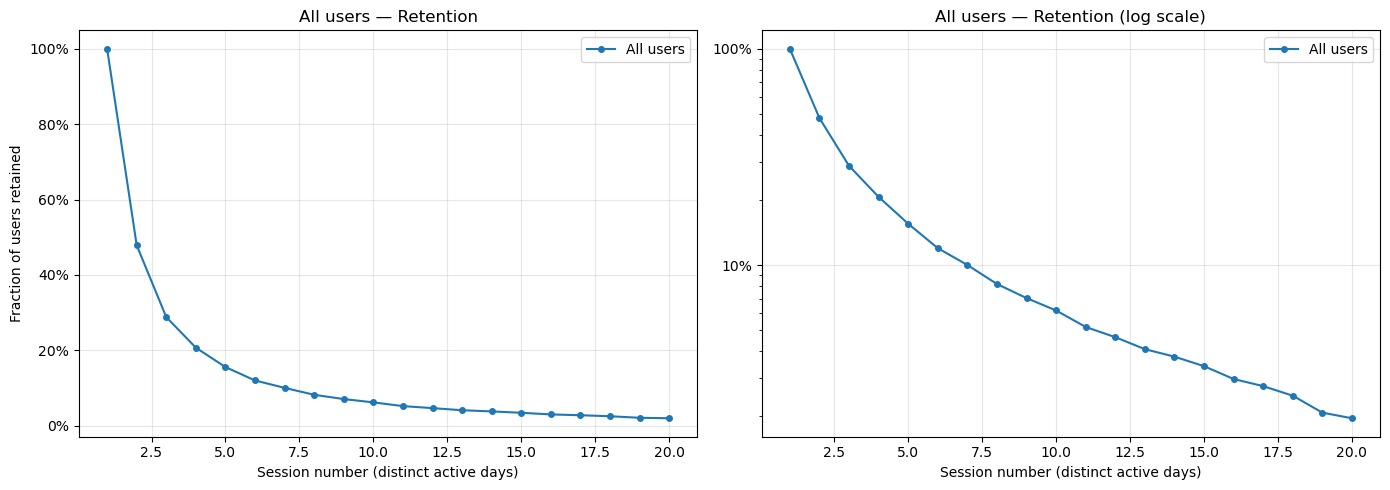

In [5]:
curve_all = retention_curve(df_all)
plot_retention_curves([curve_all], ['All users'], title='All users', max_sessions=20)

In [6]:
# Print the key drop-off numbers
for n in [1, 2, 3, 5, 10, 20]:
    if n in curve_all.index:
        print(f"Session {n:>2}: {curve_all[n]:.1%} of users")

Session  1: 100.0% of users
Session  2: 47.8% of users
Session  3: 28.8% of users
Session  5: 15.5% of users
Session 10: 6.2% of users
Session 20: 2.0% of users


---
## 2. Engagement funnel — signup → discovery → engagement
How many users make it through each stage of the core loop?

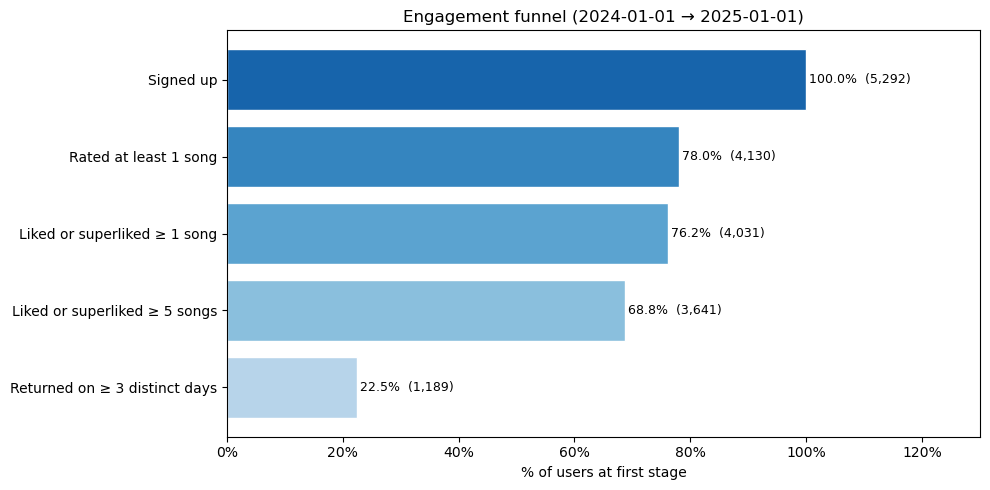

In [7]:
def count_users(sql):
    return DB.fetch(sql)[0]['cnt']

# Stage 1: signed up
n_signups = count_users(f"""
    SELECT COUNT(*) AS cnt FROM users
    WHERE timestamp > '{START}' AND timestamp < '{END}'
""")

# Stage 2: rated at least one song (any rating)
n_rated = count_users(f"""
    SELECT COUNT(DISTINCT u.id) AS cnt
    FROM users u
    WHERE u.timestamp > '{START}' AND u.timestamp < '{END}'
      AND u.id IN (
          SELECT user_id FROM user_songs
          WHERE timestamp > '{START}' AND timestamp < '{END}'
          UNION
          SELECT user_id FROM unliked_songs
          WHERE timestamp > '{START}' AND timestamp < '{END}'
      )
""")

# Stage 3: liked or superliked at least one song
n_liked = count_users(f"""
    SELECT COUNT(DISTINCT u.id) AS cnt
    FROM users u
    INNER JOIN user_songs us ON us.user_id = u.id
    WHERE u.timestamp > '{START}' AND u.timestamp < '{END}'
      AND us.timestamp > '{START}' AND us.timestamp < '{END}'
""")

# Stage 4: liked or superliked >= 5 songs
n_engaged = count_users(f"""
    SELECT COUNT(*) AS cnt FROM (
        SELECT u.id
        FROM users u
        INNER JOIN user_songs us ON us.user_id = u.id
        WHERE u.timestamp > '{START}' AND u.timestamp < '{END}'
          AND us.timestamp > '{START}' AND us.timestamp < '{END}'
        GROUP BY u.id
        HAVING COUNT(*) >= 5
    ) t
""")

# Stage 5: returned on >= 3 distinct days
n_retained = count_users(f"""
    SELECT COUNT(*) AS cnt FROM (
        SELECT r.user_id
        FROM (
            SELECT user_id, timestamp FROM user_songs
            WHERE timestamp > '{START}' AND timestamp < '{END}'
            UNION ALL
            SELECT user_id, timestamp FROM unliked_songs
            WHERE timestamp > '{START}' AND timestamp < '{END}'
        ) r
        INNER JOIN users u ON u.id = r.user_id
        WHERE u.timestamp > '{START}' AND u.timestamp < '{END}'
        GROUP BY r.user_id
        HAVING COUNT(DISTINCT DATE(r.timestamp)) >= 3
    ) t
""")

stages = [
    'Signed up',
    'Rated at least 1 song',
    'Liked or superliked ≥ 1 song',
    'Liked or superliked ≥ 5 songs',
    'Returned on ≥ 3 distinct days',
]
counts = [n_signups, n_rated, n_liked, n_engaged, n_retained]

plot_funnel_bars(stages, counts, f'Engagement funnel ({START} → {END})')

---
## 4. Spotify vs non-Spotify users

In [9]:
SPOTIFY_USERS = f"""
    AND u.id IN (
        SELECT user_id FROM eventlog
        WHERE action = 'login_with_spotify_success'
          AND timestamp > '{START}' AND timestamp < '{END}'
        GROUP BY user_id
    )
"""

NON_SPOTIFY_USERS = f"""
    AND u.id NOT IN (
        SELECT user_id FROM eventlog
        WHERE action = 'login_with_spotify_success'
          AND timestamp > '{START}' AND timestamp < '{END}'
        GROUP BY user_id
    )
"""

df_spotify     = get_session_funnel(START, END, extra_where=SPOTIFY_USERS)
df_non_spotify = get_session_funnel(START, END, extra_where=NON_SPOTIFY_USERS)

print(f"Spotify users:     {df_spotify['num_users'].sum():,}")
print(f"Non-Spotify users: {df_non_spotify['num_users'].sum():,}")

Spotify users:     2
Non-Spotify users: 4,128


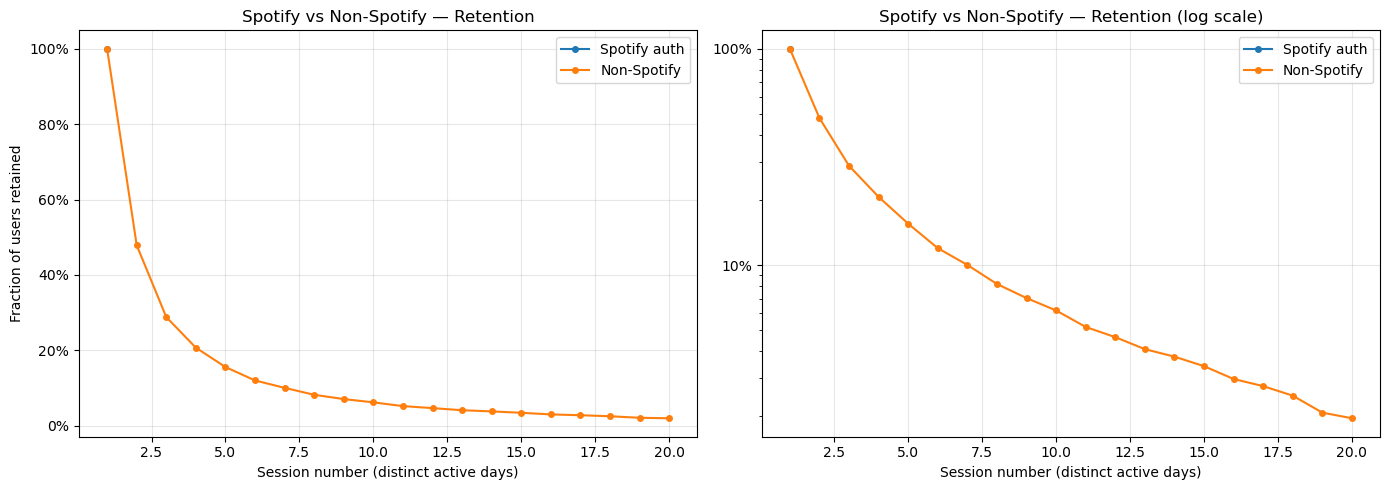

In [10]:
curve_spotify     = retention_curve(df_spotify)
curve_non_spotify = retention_curve(df_non_spotify)

plot_retention_curves(
    [curve_spotify, curve_non_spotify],
    ['Spotify auth', 'Non-Spotify'],
    title='Spotify vs Non-Spotify',
    max_sessions=20
)

---
## 4. Gender comparison

In [ ]:
MALE_USERS   = "AND u.id IN (SELECT user_id FROM user_genders WHERE LOWER(gender) = 'male')"
FEMALE_USERS = "AND u.id IN (SELECT user_id FROM user_genders WHERE LOWER(gender) = 'female')"

df_male   = get_session_funnel(START, END, extra_where=MALE_USERS)
df_female = get_session_funnel(START, END, extra_where=FEMALE_USERS)

print(f"Male users:   {df_male['num_users'].sum():,}")
print(f"Female users: {df_female['num_users'].sum():,}")

In [ ]:
curve_male   = retention_curve(df_male)
curve_female = retention_curve(df_female)

plot_retention_curves(
    [curve_male, curve_female],
    ['Male', 'Female'],
    title='Male vs Female',
    max_sessions=20
)

---
## 5. All segments together

In [ ]:
plot_retention_curves(
    [curve_all, curve_spotify, curve_non_spotify, curve_male, curve_female],
    ['All', 'Spotify auth', 'Non-Spotify', 'Male', 'Female'],
    title='All segments',
    max_sessions=20
)

---
## 6. Cohort weekly retention
For each weekly signup cohort, what fraction of users return in week 1, 2, 4?

In [11]:
sql_cohorts = f"""
    SELECT
        DATE_FORMAT(u.timestamp, '%Y-%U') AS signup_week,
        COUNT(DISTINCT u.id)              AS cohort_size,
        COUNT(DISTINCT CASE
            WHEN DATEDIFF(DATE(r.timestamp), DATE(u.timestamp)) BETWEEN 1 AND 13  THEN u.id END) AS retained_w1,
        COUNT(DISTINCT CASE
            WHEN DATEDIFF(DATE(r.timestamp), DATE(u.timestamp)) BETWEEN 7 AND 20  THEN u.id END) AS retained_w2,
        COUNT(DISTINCT CASE
            WHEN DATEDIFF(DATE(r.timestamp), DATE(u.timestamp)) BETWEEN 21 AND 34 THEN u.id END) AS retained_w4
    FROM users u
    LEFT JOIN (
        SELECT user_id, timestamp FROM user_songs
        UNION ALL
        SELECT user_id, timestamp FROM unliked_songs
    ) r ON r.user_id = u.id
    WHERE u.timestamp > '{START}' AND u.timestamp < '{END}'
    GROUP BY signup_week
    ORDER BY signup_week
"""

cohorts = pd.DataFrame(DB.fetch(sql_cohorts))
cohorts['w1_retention'] = cohorts['retained_w1'] / cohorts['cohort_size']
cohorts['w2_retention'] = cohorts['retained_w2'] / cohorts['cohort_size']
cohorts['w4_retention'] = cohorts['retained_w4'] / cohorts['cohort_size']
cohorts.tail(10)

,signup_week,cohort_size,retained_w1,retained_w2,retained_w4,w1_retention,w2_retention,w4_retention
43,2024-43,239,52,28,14,0.217573,0.117155,0.058577
44,2024-44,58,18,8,5,0.310345,0.137931,0.086207
45,2024-45,22,4,0,0,0.181818,0.000000,0.000000
46,2024-46,16,2,2,1,0.125000,0.125000,0.062500
47,2024-47,16,2,0,0,0.125000,0.000000,0.000000
48,2024-48,20,6,1,2,0.300000,0.050000,0.100000
49,2024-49,17,6,4,2,0.352941,0.235294,0.117647
50,2024-50,29,12,5,2,0.413793,0.172414,0.068966
51,2024-51,37,10,5,4,0.270270,0.135135,0.108108
52,2024-52,12,4,1,1,0.333333,0.083333,0.083333


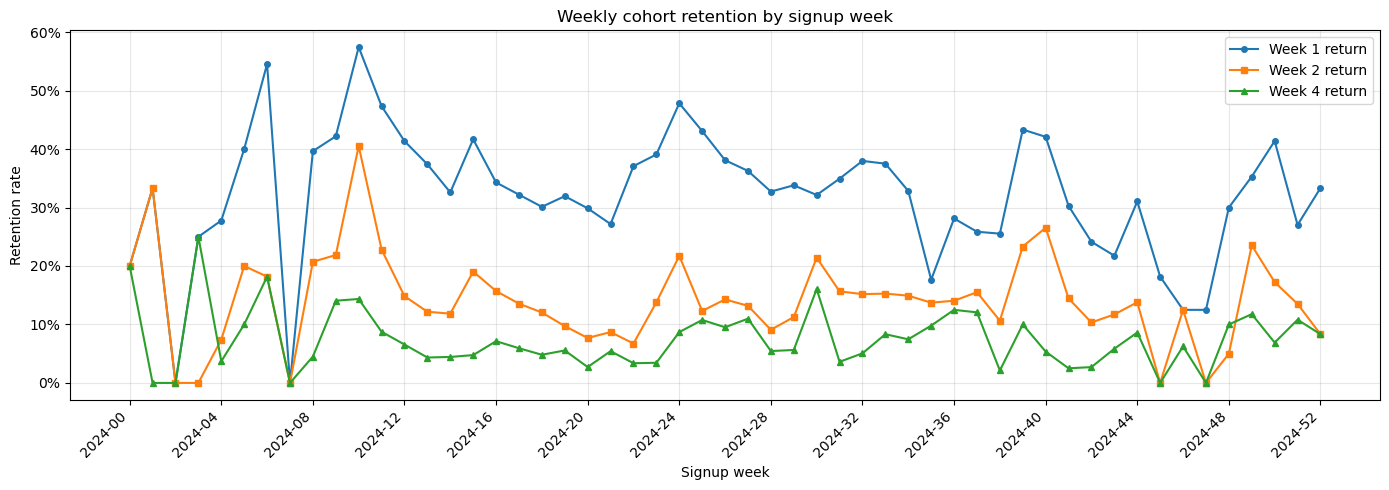

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

x = range(len(cohorts))
ax.plot(x, cohorts['w1_retention'], marker='o', markersize=4, label='Week 1 return')
ax.plot(x, cohorts['w2_retention'], marker='s', markersize=4, label='Week 2 return')
ax.plot(x, cohorts['w4_retention'], marker='^', markersize=4, label='Week 4 return')

tick_step = max(1, len(cohorts) // 12)
ax.set_xticks(list(x)[::tick_step])
ax.set_xticklabels(cohorts['signup_week'].iloc[::tick_step], rotation=45, ha='right')
ax.set_ylabel('Retention rate')
ax.set_xlabel('Signup week')
ax.set_title('Weekly cohort retention by signup week')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Summary: median retention across all cohorts
print("Median retention across all cohorts:")
print(f"  Week 1: {cohorts['w1_retention'].median():.1%}")
print(f"  Week 2: {cohorts['w2_retention'].median():.1%}")
print(f"  Week 4: {cohorts['w4_retention'].median():.1%}")

Median retention across all cohorts:
  Week 1: 32.8%
  Week 2: 13.8%
  Week 4: 6.2%


---
## 7. Session-to-session continuation probability
Given a user reaches session N, what is the probability they do session N+1?

NameError: name 'curve_ios' is not defined

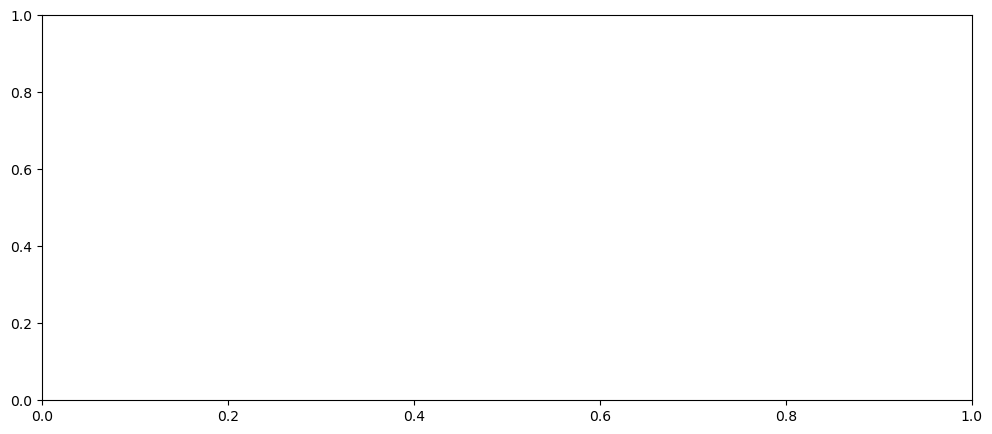

In [14]:
def continuation_prob(curve, max_sessions=20):
    """P(reach session N+1 | reached session N)"""
    curve = curve[curve.index <= max_sessions + 1]
    probs = {}
    idxs = sorted(curve.index)
    for i in range(len(idxs) - 1):
        n     = idxs[i]
        n1    = idxs[i + 1]
        if n1 == n + 1 and curve[n] > 0:
            probs[n] = curve[n1] / curve[n]
    return pd.Series(probs, name='continuation_prob')


fig, ax = plt.subplots(figsize=(12, 5))

for curve, label in [
    (curve_all,         'All'),
    (curve_spotify,     'Spotify auth'),
    (curve_non_spotify, 'Non-Spotify'),
    (curve_male,        'Male'),
    (curve_female,      'Female'),
]:
    cp = continuation_prob(curve)
    ax.plot(cp.index, cp.values, marker='o', markersize=4, label=label)

ax.set_xlabel('Session N')
ax.set_ylabel('P(session N+1 | session N)')
ax.set_title('Session-to-session continuation probability')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()